In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
# Define window size and target column
window_size = 15
target_col = "close"
target_col_idx = data.columns.get_loc(target_col)

In [4]:
# Train-val split (80% training, 20% validation)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
val_data = data.iloc[split_index:] 

print(train_data.shape)
print(val_data.shape)

(46516, 4)
(11630, 4)


In [5]:
# Fit scaler on training data only and transform both datasets
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

In [6]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [7]:
# Create sequences for training and validation
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(46501, 15, 4) (46501,)
(11615, 15, 4) (11615,)


In [8]:
# Create sequences for training and validation
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(46501, 15, 4) (46501,)
(11615, 15, 4) (11615,)


### Benchmark against a naive forecast

In [9]:
# Load test data set
test_data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_test_data.csv", index_col=0, parse_dates=True)

In [10]:
actual_test = test_data['close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_test.iloc[window_size - 1:-1].values
actual_values = actual_test.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_values - naive_predictions) / actual_values)) * 100

print(f"Naive MAE: {mae_naive:.4f}")
print(f"Naive RMSE: {rmse_naive:.4f}")
print(f"Naive MAPE: {mape_naive:.2f}%")

Naive MAE: 371.6923
Naive RMSE: 580.4977
Naive MAPE: 0.37%


In [16]:
data1 = data.copy()
data1['close_diff'] = data1['close'].diff()
data1

,open,high,low,close,close_diff
date,,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99,NaN
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00,-1.99
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49,-10.51
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32,-20.17
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90,87.58
...,...,...,...,...,...
2024-12-31 19:00:00,93760.00,94158.00,93600.00,94008.00,250.00
2024-12-31 20:00:00,94025.00,94059.00,93300.00,93415.00,-593.00
2024-12-31 21:00:00,93386.00,93777.00,93336.00,93682.00,267.00


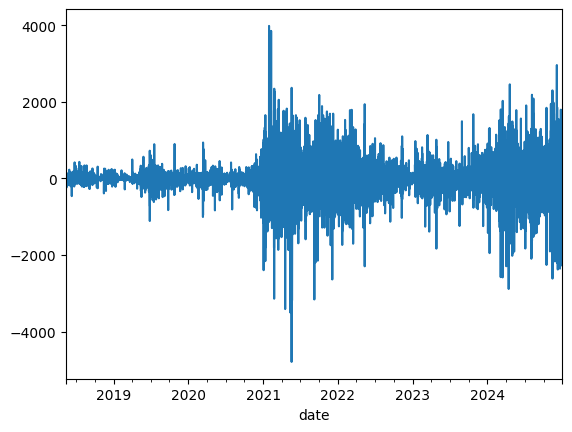

In [18]:
data1['close_diff'].plot();

In [20]:
data1['close_diff'].describe()

count    58145.000000
mean         1.455671
std        241.700253
min      -4794.690000
25%        -46.390000
50%          0.980000
75%         51.000000
max       3984.430000
Name: close_diff, dtype: float64

In [21]:
data['close'].describe()

count     58146.000000
mean      29060.513187
std       22297.945107
min        3139.760000
25%        9169.082500
50%       23872.000000
75%       43661.872500
max      108276.000000
Name: close, dtype: float64